<style>
.jp-RenderedHTMLCommon, .text_cell_render {
    font-family: Tahoma, Arial, "DejaVu Sans", sans-serif;
    font-size: 16px;
    line-height: 1.9;
    direction: rtl;
    text-align: right;
}
h1 { font-size: 32px !important; }
h2 { font-size: 26px !important; margin-top: 24px !important; }
h3 { font-size: 21px !important; margin-top: 18px !important; }
table { font-size: 15px; direction: rtl; width: 100%; }
th, td { text-align: right !important; padding: 7px !important; }
pre, code, .CodeMirror {
    font-family: "DejaVu Sans Mono", Consolas, monospace !important;
    font-size: 14px !important;
    direction: ltr;
    text-align: left;
}
.note-box {
    border: 1px solid #aaa;
    border-radius: 8px;
    padding: 12px 16px;
    margin: 12px 0;
}
</style>

<div dir="rtl">

# جلسه ۴ — روش‌های Regression و مقایسه‌ی مدل‌ها

**Machine Learning with Python**  
**مدت جلسه: ۲ ساعت**

### سؤال اصلی جلسه

> آیا می‌توان یک مسئله‌ی Regression را با روش‌های کاملاً متفاوت حل کرد؟

مسیر امروز:

**Linear → Polynomial → Polynomial + Lasso → KNN → Decision Tree → Random Forest → XGBoost → Model Comparison**

</div>

<div dir="rtl">

## اهداف یادگیری

در پایان جلسه، دانشجو باید بتواند:

- تفاوت ایده‌ی اصلی چند خانواده‌ی مهم Regression را توضیح دهد؛
- بفهمد چرا Polynomial Regression برای رابطه‌های غیرخطی مناسب است؛
- بفهمد چرا Lasso می‌تواند در مدل‌های Polynomial مفید باشد؛
- توضیح دهد چرا KNN به Scaling حساس است؛
- نقش `max_depth` در Decision Tree را توضیح دهد؛
- تفاوت ساده‌ی Random Forest و XGBoost را بیان کند؛
- مدل‌ها را با `MAE`، `RMSE` و `R²` مقایسه کند؛
- Test Set را فقط برای ارزیابی نهایی نگه دارد.

</div>

<div dir="rtl">

## زمان‌بندی پیشنهادی

| بخش | زمان |
|---|---:|
| مرور Workflow و آماده‌سازی داده | ۱۰ دقیقه |
| Linear + Polynomial | ۱۵ دقیقه |
| Polynomial + Lasso | ۱۵ دقیقه |
| KNN | ۱۵ دقیقه |
| Decision Tree | ۲۰ دقیقه |
| Random Forest | ۱۵ دقیقه |
| XGBoost | ۱۵ دقیقه |
| مقایسه مدل‌ها + Test | ۱۰ دقیقه |
| Quiz و تمرین | ۵ دقیقه |

</div>

<div dir="rtl">

## ۱. بارگذاری Dataset

همان Dataset دیابت را ادامه می‌دهیم تا دانشجو روی تفاوت مدل‌ها تمرکز کند.

- `X` = Features
- `y` = Target

</div>

In [1]:
from sklearn.datasets import load_diabetes

# Dataset دیابت را بارگذاری می‌کنیم
data = load_diabetes(as_frame=True, scaled=False)

# Features
X = data.data

# Target
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


<div dir="rtl">

## ۲. تقسیم داده به Train / Validation / Test

تقسیم داده:

- **Train:** برای آموزش مدل
- **Validation:** برای مقایسه‌ی مدل‌ها
- **Test:** فقط برای ارزیابی نهایی

تقریباً:

**60% Train / 20% Validation / 20% Test**

</div>

In [2]:
from sklearn.model_selection import train_test_split

# ابتدا 60 درصد برای Train نگه می‌داریم
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=0
)

# داده‌ی موقت را نصف می‌کنیم:
# 20 درصد Validation و 20 درصد Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=0
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (265, 10)
Validation: (88, 10)
Test: (89, 10)


<div dir="rtl">

## ۳. معیارهای ارزیابی

در این جلسه سه معیار را می‌بینیم:

- **MAE:** هرچه کمتر باشد بهتر است.
- **RMSE:** هرچه کمتر باشد بهتر است.
- **R²:** معمولاً هرچه بیشتر باشد بهتر است.

برای ساده ماندن کد، در هر بخش فقط همان کتابخانه‌هایی را import می‌کنیم که لازم داریم.

</div>

<div dir="rtl">

## ۴. Baseline Model

قبل از مدل‌های اصلی، یک مدل خیلی ساده می‌سازیم.

`DummyRegressor(strategy="mean")`

این مدل همیشه میانگین Target در Train Data را پیش‌بینی می‌کند.

</div>

In [3]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# مدل پایه
baseline = DummyRegressor(strategy="mean")

# آموزش
baseline.fit(X_train, y_train)

# پیش‌بینی روی Validation
pred_baseline = baseline.predict(X_val)

# معیارها
baseline_mae = mean_absolute_error(y_val, pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_val, pred_baseline))
baseline_r2 = r2_score(y_val, pred_baseline)

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R2:", round(baseline_r2, 3))

Baseline MAE: 65.62
Baseline RMSE: 78.14
Baseline R2: -0.003


<div dir="rtl">

## ۵. Linear Regression

Linear Regression تلاش می‌کند یک رابطه‌ی خطی بین Features و Target پیدا کند.

این مدل را قبلاً دیده‌ایم و اینجا فقط به‌عنوان **Reference Model** استفاده می‌کنیم.

</div>

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# مدل Linear Regression
linear_model = LinearRegression()

# آموزش
linear_model.fit(X_train, y_train)

# پیش‌بینی
pred_linear = linear_model.predict(X_val)

# معیارها
linear_mae = mean_absolute_error(y_val, pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_val, pred_linear))
linear_r2 = r2_score(y_val, pred_linear)

print("Linear MAE:", round(linear_mae, 2))
print("Linear RMSE:", round(linear_rmse, 2))
print("Linear R2:", round(linear_r2, 3))

Linear MAE: 48.2
Linear RMSE: 58.27
Linear R2: 0.443


<div dir="rtl">

## ۶. Polynomial Regression

### ایده‌ی اصلی

گاهی رابطه‌ی بین `X` و `y` خط مستقیم نیست.

Polynomial Regression ویژگی‌های جدیدی می‌سازد، مثلاً:

- `x²`
- `x³`
- `x1 × x2`

سپس روی این Features جدید، Linear Regression اجرا می‌شود.

</div>

<div dir="rtl">

### Linear در برابر Polynomial

<div style="text-align:center;">
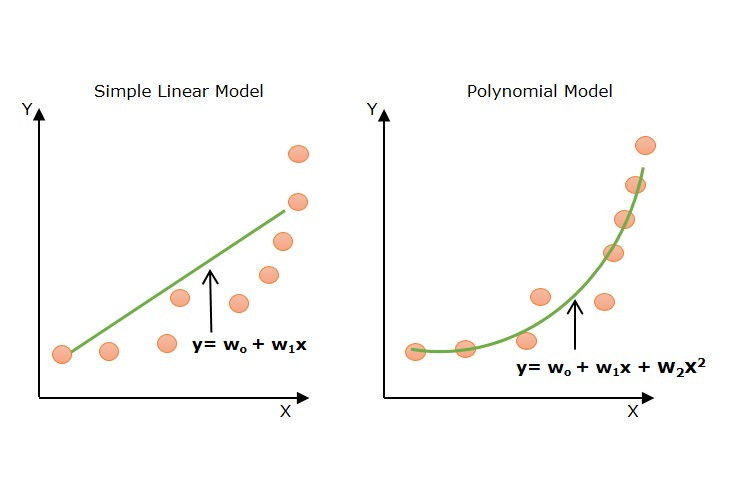
</div>
<p style='text-align:center; font-size:14px;'><b>سمت چپ: رابطه‌ی خطی — سمت راست: مدل Polynomial می‌تواند رابطه‌ی خمیده را دنبال کند.</b></p>

</div>

In [11]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Polynomial Features با درجه 2
poly = PolynomialFeatures(
    degree=1,
    include_bias=False
)

# فقط روی Train یاد می‌گیریم
X_train_poly = poly.fit_transform(X_train)

# همان تبدیل را روی Validation اعمال می‌کنیم
X_val_poly = poly.transform(X_val)

# مدل Linear Regression روی Polynomial Features
poly_model = LinearRegression()

# آموزش
poly_model.fit(X_train_poly, y_train)

# پیش‌بینی
pred_poly = poly_model.predict(X_val_poly)

# معیارها
poly_mae = mean_absolute_error(y_val, pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_val, pred_poly))
poly_r2 = r2_score(y_val, pred_poly)

print("Polynomial MAE:", round(poly_mae, 2))
print("Polynomial RMSE:", round(poly_rmse, 2))
print("Polynomial R2:", round(poly_r2, 3))

Polynomial MAE: 48.2
Polynomial RMSE: 58.27
Polynomial R2: 0.443


<div dir="rtl" class="note-box">

### نکته

Polynomial Regression می‌تواند مدل را انعطاف‌پذیرتر کند.

اما اگر Degree خیلی بالا باشد، تعداد Features زیاد می‌شود و خطر **Overfitting** بیشتر می‌شود.

</div>

<div dir="rtl">

## ۷. Polynomial + Lasso

### چرا Lasso را بعد از Polynomial اضافه می‌کنیم؟

Polynomial Features می‌تواند تعداد زیادی Feature جدید بسازد.

مثلاً:

`bmi`, `bp`, `bmi²`, `bp²`, `bmi × bp`, ...

وقتی Featureها زیاد می‌شوند، مدل ممکن است پیچیده شود.

**Lasso** با اضافه کردن Penalty تلاش می‌کند بعضی Coefficientها را کوچک کند و بعضی را حتی به صفر برساند.

پس ایده‌ی این بخش:

> **Polynomial = ساخت Features بیشتر**  
> **Lasso = کنترل کردن مدل و حذف بعضی اثرهای ضعیف**

</div>

In [46]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) ساخت Polynomial Features
poly_lasso = PolynomialFeatures(
    degree=2,
    include_bias=True
)

X_train_poly_lasso = poly_lasso.fit_transform(X_train)
X_val_poly_lasso = poly_lasso.transform(X_val)

# 2) Scaling
# Lasso به مقیاس Features حساس است
scaler_poly = StandardScaler()

X_train_poly_lasso = scaler_poly.fit_transform(X_train_poly_lasso)
X_val_poly_lasso = scaler_poly.transform(X_val_poly_lasso)

# 3) ساخت مدل Lasso
poly_lasso_model = Lasso(
    alpha=1,
    max_iter=10000
)

############## alpha = 2.2

# 4) آموزش مدل
poly_lasso_model.fit(
    X_train_poly_lasso,
    y_train
)

# 5) پیش‌بینی
pred_poly_lasso = poly_lasso_model.predict(
    X_val_poly_lasso
)

# 6) معیارها
poly_lasso_mae = mean_absolute_error(
    y_val,
    pred_poly_lasso
)

poly_lasso_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred_poly_lasso
    )
)

poly_lasso_r2 = r2_score(
    y_val,
    pred_poly_lasso
)

print("Polynomial + Lasso MAE:", round(poly_lasso_mae, 2))
print("Polynomial + Lasso RMSE:", round(poly_lasso_rmse, 2))
print("Polynomial + Lasso R2:", round(poly_lasso_r2, 3))

Polynomial + Lasso MAE: 47.77
Polynomial + Lasso RMSE: 58.26
Polynomial + Lasso R2: 0.443


In [38]:
# تعداد کل Polynomial Features
total_features = len(
    poly_lasso.get_feature_names_out()
)

# تعداد Coefficientهایی که Lasso صفر کرده است
zero_coefficients = (
    poly_lasso_model.coef_ == 0
).sum()

print("Total Polynomial Features:", total_features)
print("Zero Coefficients:", zero_coefficients)

Total Polynomial Features: 65
Zero Coefficients: 52


<div dir="rtl">

## ۸. KNN Regression

### ایده‌ی اصلی

KNN برای یک Observation جدید:

1. نزدیک‌ترین Observationهای Train را پیدا می‌کند؛
2. Target آن‌ها را بررسی می‌کند؛
3. میانگین Target آن‌ها را به‌عنوان Prediction استفاده می‌کند.

اگر `K = 3` باشد، مدل از **۳ همسایه‌ی نزدیک‌تر** استفاده می‌کند.

</div>

<div dir="rtl">

### ایده‌ی KNN Regression

<div style="text-align:center;">
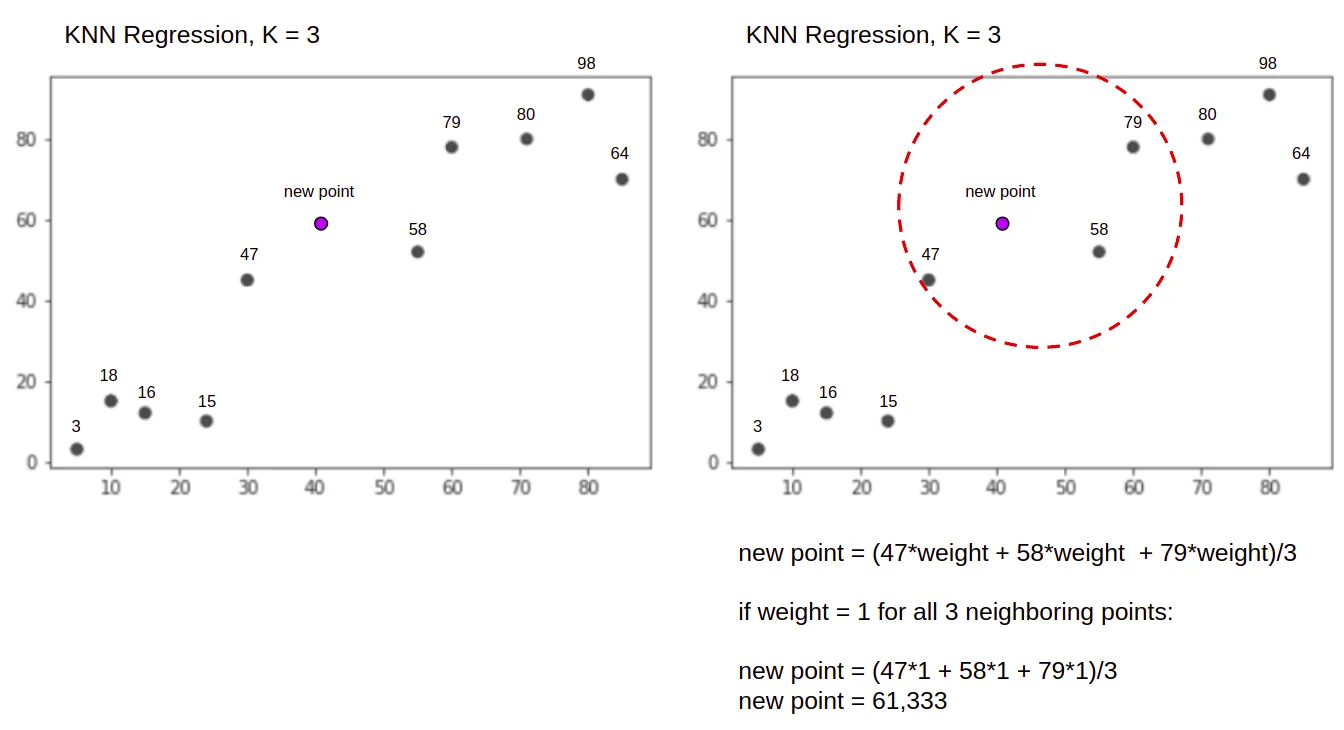
</div>
<p style='text-align:center; font-size:14px;'><b>نقطه‌ی جدید با استفاده از نزدیک‌ترین همسایه‌ها پیش‌بینی می‌شود.</b></p>

</div>

<div dir="rtl" class="note-box">

### چرا Scaling مهم است؟

KNN بر اساس **Distance** کار می‌کند.

اگر یک Feature بازه‌ی عددی خیلی بزرگ‌تری داشته باشد، ممکن است محاسبه‌ی فاصله را بیش از حد تحت تأثیر قرار دهد.

پس قبل از KNN، Features را Standardize می‌کنیم.

</div>

In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scaling
scaler_knn = StandardScaler()

X_train_scaled = scaler_knn.fit_transform(X_train)
X_val_scaled = scaler_knn.transform(X_val)

# مدل KNN با 5 همسایه
knn_model = KNeighborsRegressor(
    n_neighbors=5
)


############## n_neighbors=12

# آموزش
knn_model.fit(
    X_train_scaled,
    y_train
)

# پیش‌بینی
pred_knn = knn_model.predict(
    X_val_scaled
)

# معیارها
knn_mae = mean_absolute_error(
    y_val,
    pred_knn
)

knn_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred_knn
    )
)

knn_r2 = r2_score(
    y_val,
    pred_knn
)

print("KNN MAE:", round(knn_mae, 2))
print("KNN RMSE:", round(knn_rmse, 2))
print("KNN R2:", round(knn_r2, 3))

KNN MAE: 46.5
KNN RMSE: 58.39
KNN R2: 0.44


<div dir="rtl">

## ۹. Decision Tree Regression

### ایده‌ی اصلی

Decision Tree با سؤال‌های ساده، داده را به Branchهای مختلف تقسیم می‌کند.

مثلاً:

> آیا `bmi` از یک مقدار مشخص کمتر است؟

بعد ممکن است سؤال بعدی روی `bp` یا `s5` باشد.

در انتهای هر مسیر، مدل یک مقدار را به‌عنوان Prediction می‌دهد.

</div>

<div dir="rtl">

### Decision Tree با Variableهای Dataset خودمان

<div style="text-align:center;">
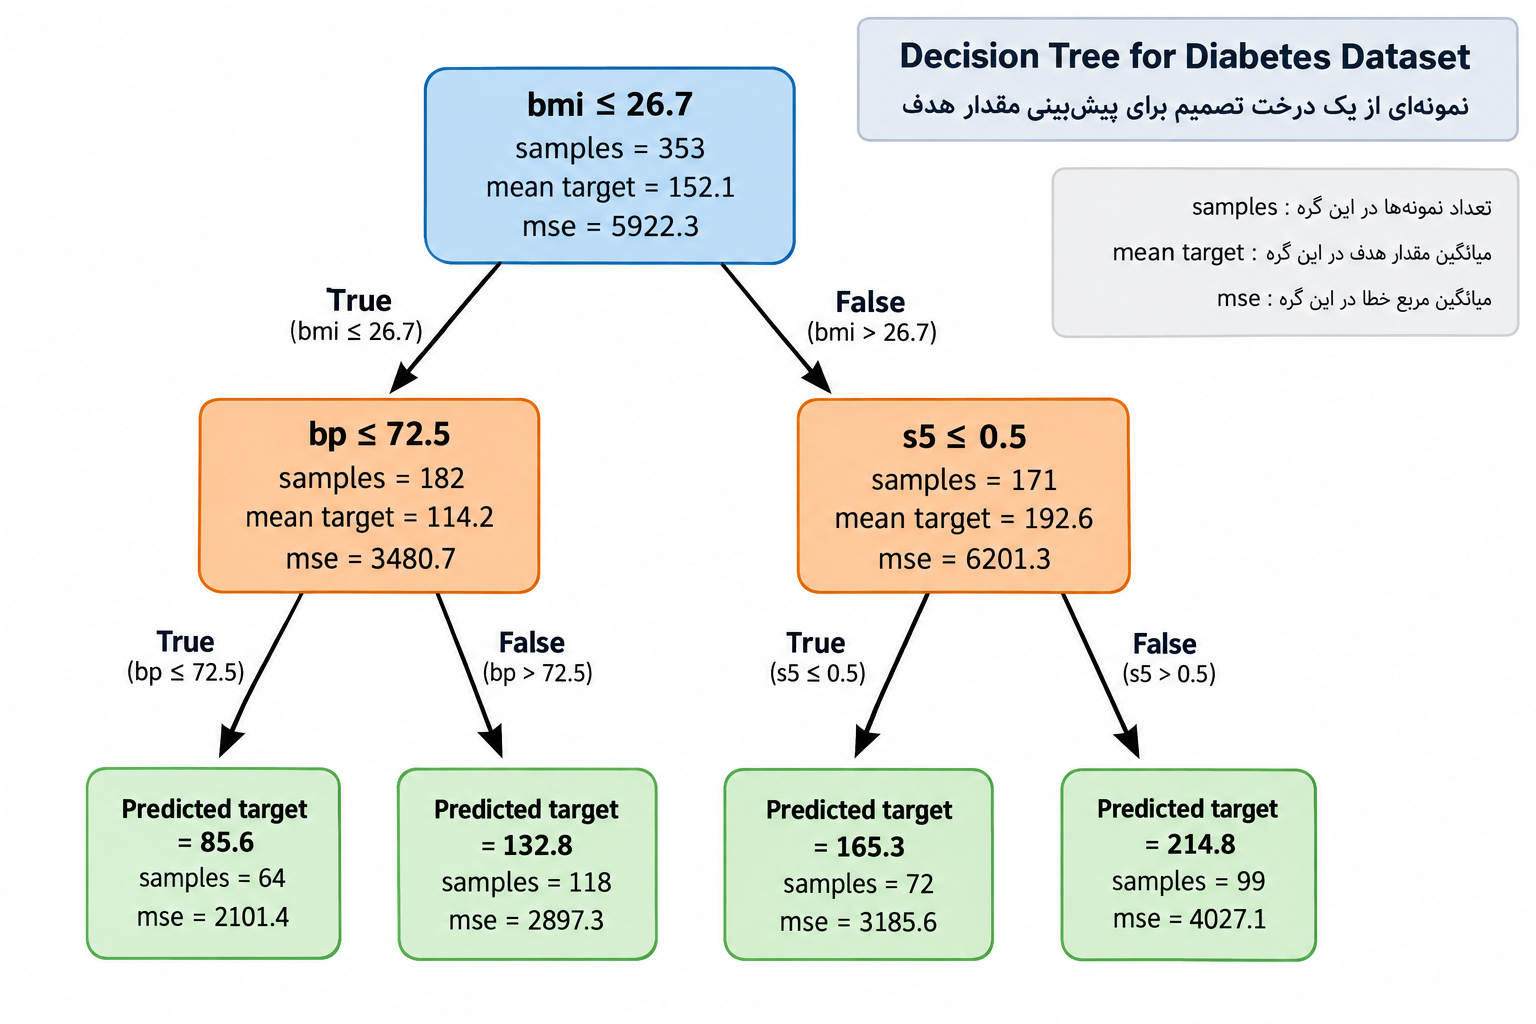
</div>
<p style='text-align:center; font-size:14px;'><b>نمونه‌ی آموزشی از Split روی bmi، bp و s5 برای پیش‌بینی Target.</b></p>

</div>

<div dir="rtl" class="note-box">

### `max_depth`

`max_depth` تعیین می‌کند درخت چقدر اجازه دارد عمیق شود.

- Depth خیلی کم → احتمال **Underfitting**
- Depth خیلی زیاد → احتمال **Overfitting**

Tree-based modelها معمولاً برای Split کردن به `StandardScaler` نیاز ندارند.

</div>

In [43]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# مدل Decision Tree
tree_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=0
)

########## max_depth=3

# آموزش
tree_model.fit(
    X_train,
    y_train
)

# پیش‌بینی
pred_tree = tree_model.predict(
    X_val
)

# معیارها
tree_mae = mean_absolute_error(
    y_val,
    pred_tree
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred_tree
    )
)

tree_r2 = r2_score(
    y_val,
    pred_tree
)

print("Decision Tree MAE:", round(tree_mae, 2))
print("Decision Tree RMSE:", round(tree_rmse, 2))
print("Decision Tree R2:", round(tree_r2, 3))

Decision Tree MAE: 51.12
Decision Tree RMSE: 65.81
Decision Tree R2: 0.289


<div dir="rtl">

## ۱۰. Random Forest Regression

### ایده‌ی اصلی

یک Decision Tree ممکن است ناپایدار باشد.

Random Forest تعداد زیادی Decision Tree می‌سازد.

هر Tree یک Prediction می‌دهد و در پایان Predictionها با هم ترکیب می‌شوند.

این ایده نمونه‌ای از **Ensemble Learning** است.

</div>

<div dir="rtl">

### Single Decision Tree در برابر Tree Ensemble

<div style="text-align:center;">
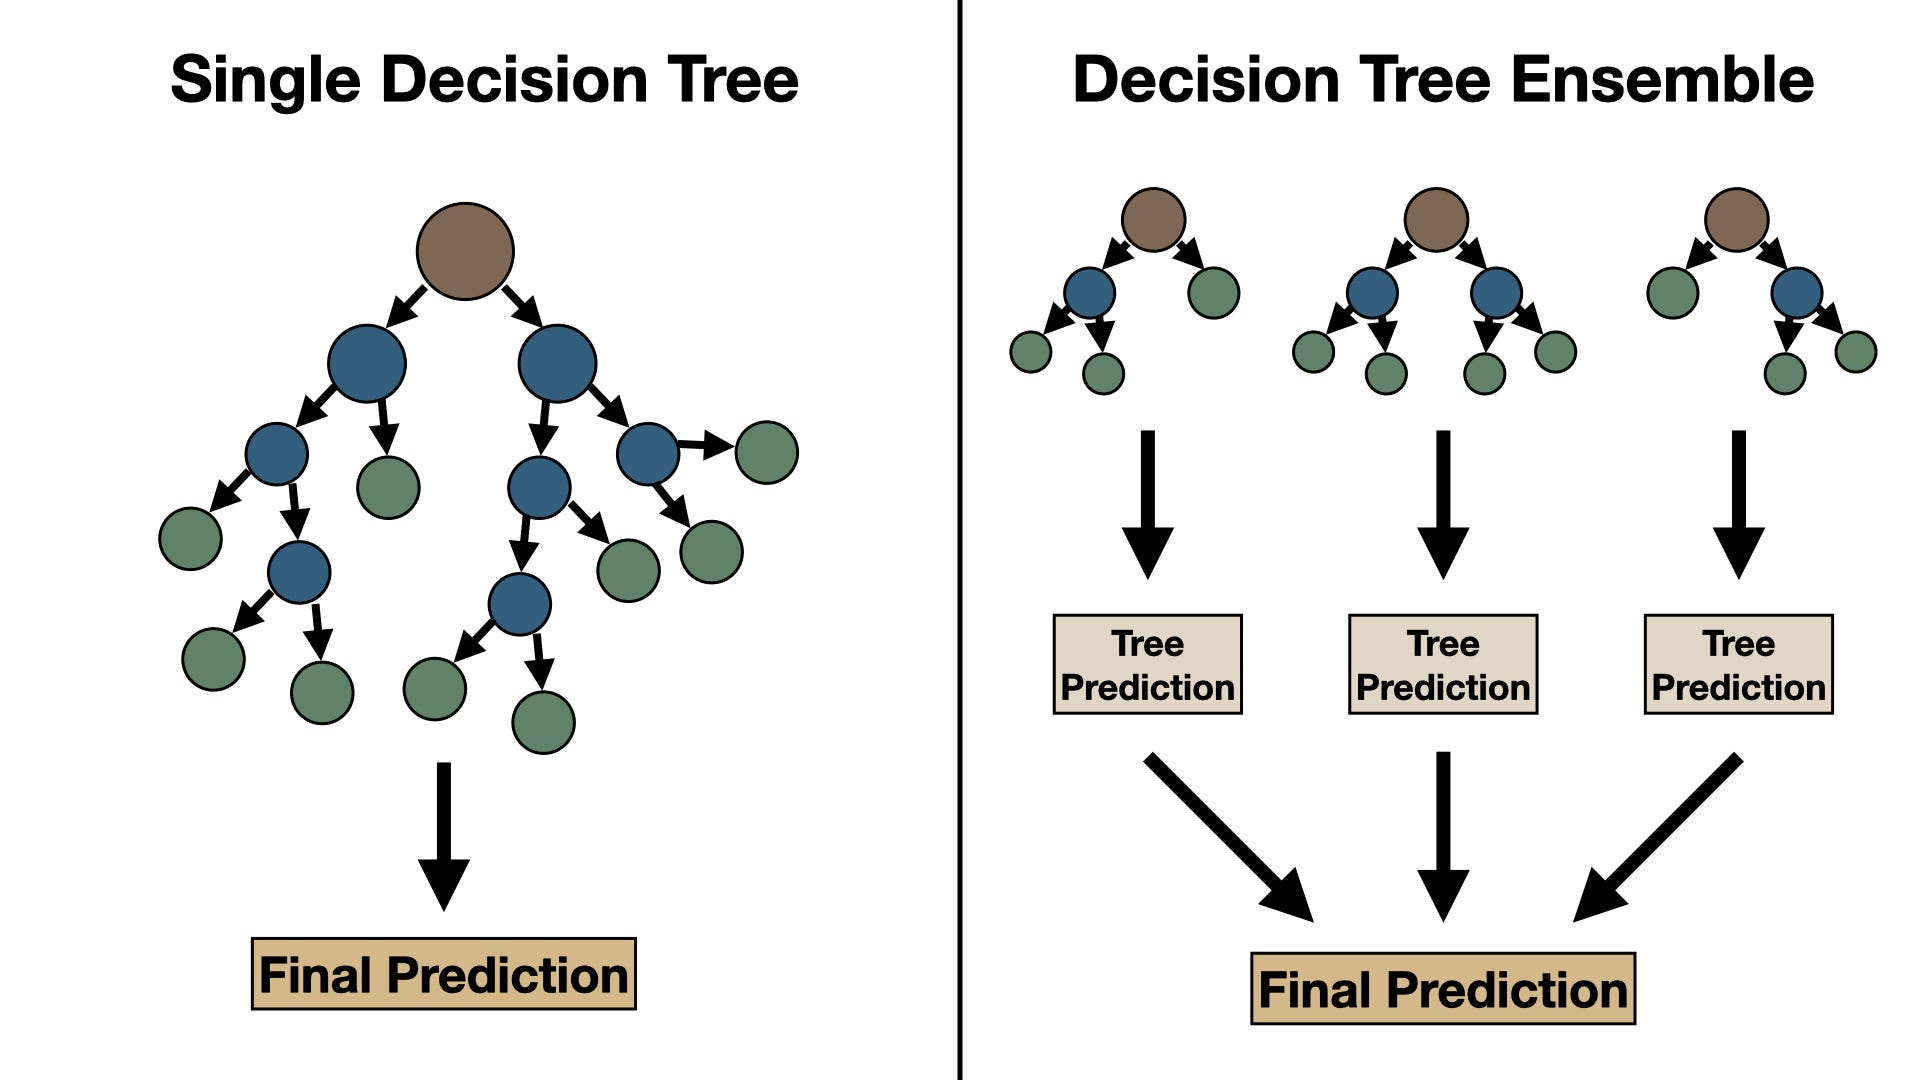
</div>
<p style='text-align:center; font-size:14px;'><b>Random Forest به‌جای یک Tree، از مجموعه‌ای از Treeها استفاده می‌کند.</b></p>

</div>

In [44]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# مدل Random Forest
forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=0
)

# آموزش
forest_model.fit(
    X_train,
    y_train
)

# پیش‌بینی
pred_forest = forest_model.predict(
    X_val
)

# معیارها
forest_mae = mean_absolute_error(
    y_val,
    pred_forest
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred_forest
    )
)

forest_r2 = r2_score(
    y_val,
    pred_forest
)

print("Random Forest MAE:", round(forest_mae, 2))
print("Random Forest RMSE:", round(forest_rmse, 2))
print("Random Forest R2:", round(forest_r2, 3))

Random Forest MAE: 50.18
Random Forest RMSE: 60.56
Random Forest R2: 0.398


<div dir="rtl">

## ۱۱. XGBoost Regression

### ایده‌ی اصلی

در Random Forest، چند Tree ساخته می‌شوند و Prediction آن‌ها با هم ترکیب می‌شود.

در XGBoost، Treeها **مرحله‌به‌مرحله** ساخته می‌شوند.

ایده‌ی خیلی ساده:

1. Tree اول Prediction می‌دهد.
2. خطاهای باقی‌مانده بررسی می‌شوند.
3. Tree بعدی تلاش می‌کند بخشی از خطاهای قبلی را کاهش دهد.
4. این روند چند بار ادامه پیدا می‌کند.

### سه Hyperparameter مهم امروز

- `n_estimators` = تعداد Treeها
- `learning_rate` = میزان اثر هر مرحله
- `max_depth` = عمق هر Tree

</div>

In [47]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# مدل XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=0,
    objective="reg:squarederror"
)

# آموزش
xgb_model.fit(
    X_train,
    y_train
)

# پیش‌بینی
pred_xgb = xgb_model.predict(
    X_val
)

# معیارها
xgb_mae = mean_absolute_error(
    y_val,
    pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        pred_xgb
    )
)

xgb_r2 = r2_score(
    y_val,
    pred_xgb
)

print("XGBoost MAE:", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))
print("XGBoost R2:", round(xgb_r2, 3))

XGBoost MAE: 50.9
XGBoost RMSE: 63.75
XGBoost R2: 0.333


<div dir="rtl">

## ۱۲. مقایسه‌ی مدل‌ها

همه‌ی مدل‌ها روی **همان Validation Set** مقایسه می‌شوند.

این نکته خیلی مهم است:

> مدل پیچیده‌تر لزوماً مدل بهتری نیست.

</div>

In [48]:
import pandas as pd

# جدول مقایسه
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Polynomial Regression",
        "Polynomial + Lasso",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        poly_mae,
        poly_lasso_mae,
        knn_mae,
        tree_mae,
        forest_mae,
        xgb_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        poly_rmse,
        poly_lasso_rmse,
        knn_rmse,
        tree_rmse,
        forest_rmse,
        xgb_rmse
    ],

    "R2": [
        baseline_r2,
        linear_r2,
        poly_r2,
        poly_lasso_r2,
        knn_r2,
        tree_r2,
        forest_r2,
        xgb_r2
    ]
})

# مرتب‌سازی بر اساس MAE
comparison = comparison.sort_values("MAE")

print(comparison.round(3))

                   Model     MAE    RMSE     R2
4                    KNN  46.505  58.391  0.440
3     Polynomial + Lasso  47.768  58.256  0.443
2  Polynomial Regression  48.200  58.265  0.443
1      Linear Regression  48.200  58.265  0.443
6          Random Forest  50.183  60.561  0.398
7                XGBoost  50.900  63.749  0.333
5          Decision Tree  51.117  65.805  0.289
0               Baseline  65.620  78.139 -0.003


<div dir="rtl">

## ۱۳. Final Test Comparison

تا این مرحله، از Test Set برای انتخاب مدل یا تنظیم Hyperparameterها استفاده نکرده‌ایم.

اکنون همه‌ی مدل‌ها با همان Hyperparameterهایی که بر اساس Validation Set انتخاب شده‌اند، یک‌بار روی Test Set ارزیابی می‌شوند.

هدف این مرحله بررسی عملکرد نهایی مدل‌ها روی داده‌هایی است که در فرایند آموزش و تنظیم مدل استفاده نشده‌اند.

### نکته‌ی مهم

بعد از مشاهده‌ی نتایج Test Set، دیگر Hyperparameterها را تغییر نمی‌دهیم.

در غیر این صورت، Test Set نیز وارد فرایند Model Selection می‌شود و دیگر یک ارزیابی مستقل نخواهد بود.

</div>

In [51]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# آماده‌سازی Test Data برای مدل‌های مختلف
# ==========================================

# Polynomial Regression
X_test_poly = poly.transform(X_test)

# Polynomial + Lasso
X_test_poly_lasso = poly_lasso.transform(X_test)
X_test_poly_lasso = scaler_poly.transform(X_test_poly_lasso)

# KNN
X_test_scaled = scaler_knn.transform(X_test)


# ==========================================
# Prediction روی Test Set
# ==========================================

pred_test_baseline = baseline.predict(X_test)

pred_test_linear = linear_model.predict(X_test)

pred_test_poly = poly_model.predict(X_test_poly)

pred_test_poly_lasso = poly_lasso_model.predict(
    X_test_poly_lasso
)

pred_test_knn = knn_model.predict(
    X_test_scaled
)

pred_test_tree = tree_model.predict(X_test)

pred_test_forest = forest_model.predict(X_test)

pred_test_xgb = xgb_model.predict(X_test)


# ==========================================
# ساخت جدول نتایج
# ==========================================

models = [
    "Baseline",
    "Linear Regression",
    "Polynomial Regression",
    "Polynomial + Lasso",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

predictions = [
    pred_test_baseline,
    pred_test_linear,
    pred_test_poly,
    pred_test_poly_lasso,
    pred_test_knn,
    pred_test_tree,
    pred_test_forest,
    pred_test_xgb
]


results = []

for model_name, pred in zip(models, predictions):

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


test_results = pd.DataFrame(results)

# مرتب‌سازی بر اساس MAE
test_results = test_results.sort_values("MAE")

print(test_results.round(3))

                   Model     MAE    RMSE     R2
3     Polynomial + Lasso  42.091  53.945  0.341
4                    KNN  42.403  53.266  0.358
1      Linear Regression  42.943  55.437  0.304
2  Polynomial Regression  42.943  55.437  0.304
6          Random Forest  43.785  55.559  0.301
7                XGBoost  46.284  59.624  0.195
5          Decision Tree  49.173  64.005  0.073
0               Baseline  56.031  66.672 -0.006


<div dir="rtl">

## ۱۴. خلاصه‌ی مدل‌ها

| مدل | ایده‌ی اصلی | Scaling؟ | Hyperparameter مهم |
|---|---|---:|---|
| Linear Regression | رابطه‌ی خطی | ضروری نیست | — |
| Polynomial | ساخت Features غیرخطی | بسته به مدل بعدی | `degree` |
| Polynomial + Lasso | Polynomial Features + Regularization | **بله** | `degree`, `alpha` |
| KNN | استفاده از نزدیک‌ترین Observationها | **بله** | `n_neighbors` |
| Decision Tree | Splitهای Rule-based | خیر | `max_depth` |
| Random Forest | تعداد زیادی Tree + ترکیب Predictionها | خیر | `n_estimators`, `max_depth` |
| XGBoost | Treeهای متوالی برای کاهش خطا | معمولاً خیر | `n_estimators`, `learning_rate`, `max_depth` |

</div>

<div dir="rtl">

## ۱۵. Quiz کوتاه

### سؤال ۱
کدام مدل به Scaling حساس‌تر است؟

A. Decision Tree  
B. KNN  
C. Random Forest

### سؤال ۲
چرا بعد از Polynomial Regression از Lasso استفاده کردیم؟

A. برای زیاد کردن تعداد Features  
B. برای کنترل پیچیدگی و کوچک کردن بعضی Coefficientها  
C. برای تبدیل Regression به Classification

### سؤال ۳
`max_depth` در Decision Tree چه چیزی را کنترل می‌کند؟

A. تعداد ستون‌ها  
B. عمق درخت  
C. مقدار Target

### سؤال ۴
Random Forest چه کاری انجام می‌دهد؟

A. فقط یک Tree می‌سازد  
B. چند Tree می‌سازد و Predictionها را ترکیب می‌کند  
C. نزدیک‌ترین همسایه‌ها را پیدا می‌کند

### سؤال ۵
در XGBoost، Tree جدید چه هدفی دارد؟

A. کاهش بخشی از خطاهای مراحل قبلی  
B. حذف همه Features  
C. تبدیل Target به Category

### سؤال ۶
کدام Dataset باید تا انتهای Model Selection دست‌نخورده بماند؟

A. Train  
B. Validation  
C. Test

### سؤال ۷
اگر MAE کمتر شود، معمولاً بهتر است یا بدتر؟

### سؤال ۸
آیا پیچیده‌ترین مدل همیشه بهترین مدل است؟

</div>

<div dir="rtl">

<details>
<summary><b>پاسخ Quiz — برای مشاهده کلیک کنید</b></summary>

1. **B — KNN**  
2. **B — کنترل پیچیدگی و کوچک کردن Coefficientها**  
3. **B — عمق درخت**  
4. **B — چند Tree و ترکیب Predictionها**  
5. **A — کاهش خطاهای قبلی**  
6. **C — Test**  
7. **MAE کمتر بهتر است.**  
8. **خیر.**

</details>

</div>

<div dir="rtl">

## ۱۶. تمرین ۱ — KNN

مقادیر زیر را برای `n_neighbors` امتحان کنید:

- `3`
- `5`
- `10`

برای هرکدام Validation MAE را حساب کنید.

### سؤال

کدام مقدار K بهترین نتیجه را روی Validation داده است؟

</div>

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

# مقدار K را تغییر دهید
k = 3

# مدل
model = KNeighborsRegressor(
    n_neighbors=k
)

# آموزش
model.fit(
    X_train_scaled,
    y_train
)

# پیش‌بینی
pred = model.predict(
    X_val_scaled
)

# MAE
mae = mean_absolute_error(
    y_val,
    pred
)

print("K =", k)
print("Validation MAE =", round(mae, 2))

<div dir="rtl">

## ۱۷. تمرین ۲ — Decision Tree

مقادیر زیر را برای `max_depth` امتحان کنید:

- `2`
- `4`
- `8`

Validation MAE را مقایسه کنید.

### سؤال

آیا افزایش Depth همیشه عملکرد Validation را بهتر می‌کند؟

</div>

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# مقدار Depth را تغییر دهید
depth = 2

# مدل
model = DecisionTreeRegressor(
    max_depth=depth,
    random_state=0
)

# آموزش
model.fit(
    X_train,
    y_train
)

# پیش‌بینی
pred = model.predict(
    X_val
)

# MAE
mae = mean_absolute_error(
    y_val,
    pred
)

print("max_depth =", depth)
print("Validation MAE =", round(mae, 2))

<div dir="rtl">

# جمع‌بندی جلسه ۴

امروز دیدیم که برای یک مسئله‌ی Regression می‌توان از روش‌های کاملاً متفاوت استفاده کرد:

- **Linear:** یک رابطه‌ی خطی
- **Polynomial:** رابطه‌ی غیرخطی با Features جدید
- **Polynomial + Lasso:** Polynomial همراه با کنترل پیچیدگی
- **KNN:** Prediction بر اساس همسایه‌های نزدیک
- **Decision Tree:** Rule و Split
- **Random Forest:** ترکیب چند Tree
- **XGBoost:** Treeهای متوالی برای کاهش خطا

مهم‌ترین پیام جلسه:

> **مدل را بر اساس عملکرد روی Validation Data انتخاب می‌کنیم، نه بر اساس پیچیده‌تر بودن اسم Algorithm.**

</div>